In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_df = pd.read_csv("../data/train.csv")

# Data Overview

In [3]:
train_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
# Check the columns of the data
print(f"Columns in the train dataset: {train_df.columns.tolist()}")

Columns in the train dataset: ['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [5]:
# Check the shape of the data
print(f"The data has {train_df.shape[0]} rows and {train_df.shape[1]} columns.")

The data has 103904 rows and 25 columns.


In [6]:
train_df.dtypes

Unnamed: 0                             int64
id                                     int64
Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure 

In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      103904 non-null

In [8]:
train_df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,51951.500000,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,29994.645522,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25975.750000,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51951.500000,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,77927.250000,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [9]:
# Check for duplicate values in the data
train_df.duplicated().sum()

np.int64(0)

In [10]:
# Check for missing values
train_df.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

# Data Cleaning

In [11]:
df = train_df.copy()

In [12]:
# Dropped unnecessary columns
df.drop(columns=['Unnamed: 0', 'id'], inplace=True)

In [13]:
# Filled missing values with median(Robust to outliers)
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

In [14]:
# Feature Encoding
df['satisfaction'] = df['satisfaction'].map({
    'neutral or dissatisfied': 0,
    'satisfied': 1
})

In [15]:
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,1
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,1


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  str    
 1   Customer Type                      103904 non-null  str    
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  str    
 4   Class                              103904 non-null  str    
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding                    103904 non-null

# Exploratory Data Analysis

In [17]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'str']).columns

print(f"The data has {len(numerical_cols)} numerical columns: {numerical_cols.tolist()}")
print(f"The data has {len(categorical_cols)} categorical columns: {categorical_cols.tolist()}")

The data has 19 numerical columns: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']
The data has 4 categorical columns: ['Gender', 'Customer Type', 'Type of Travel', 'Class']


In [18]:
numerical_columns = ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
categorical_columns = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
target = 'satisfaction'

# Distribution of target

[Text(0, 0, '58879'), Text(0, 0, '45025')]

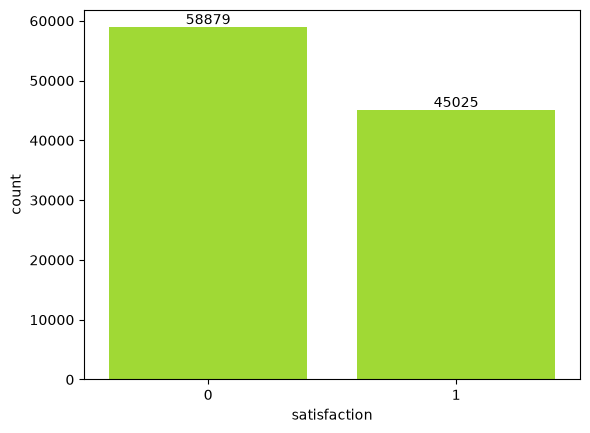

In [19]:
ax = sns.countplot(x='satisfaction', data=df, color="#A8F41A")
ax.bar_label(ax.containers[0])

### **Customer Satisfaction Distribution**
* **Neutral / Dissatisfied:** 58,879 `(56.7%)`
* **Satisfied:** 45,025 `(43.3%)`

**Conclusion:** The dataset is fairly balanced, making it well-suited for training classification models without severe class imbalance issues.

# Univariate Analysis of categorical variables

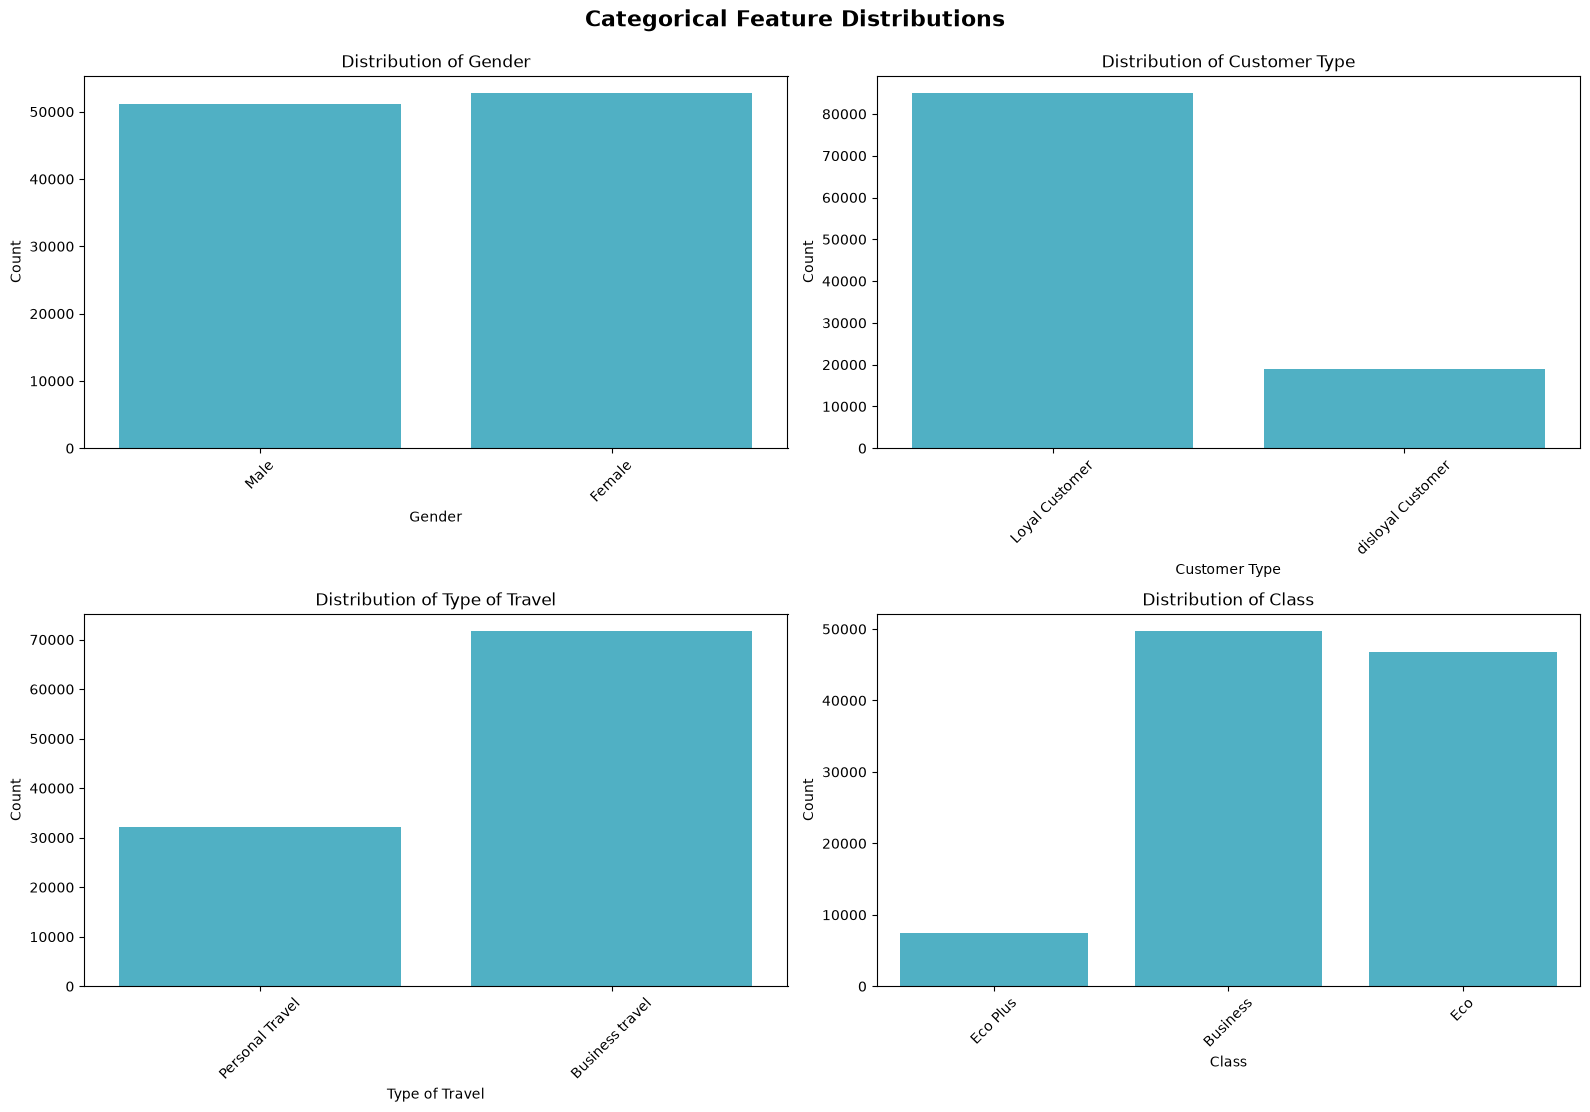

In [20]:
plt.figure(figsize=(16, 15))
for i, feature in enumerate(categorical_columns, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df, x=feature, color="#3DBDD7")
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Categorical Feature Distributions", fontsize=16, y=1.02, fontweight='bold')
plt.show()

# Univariate Analysis of numerical variables

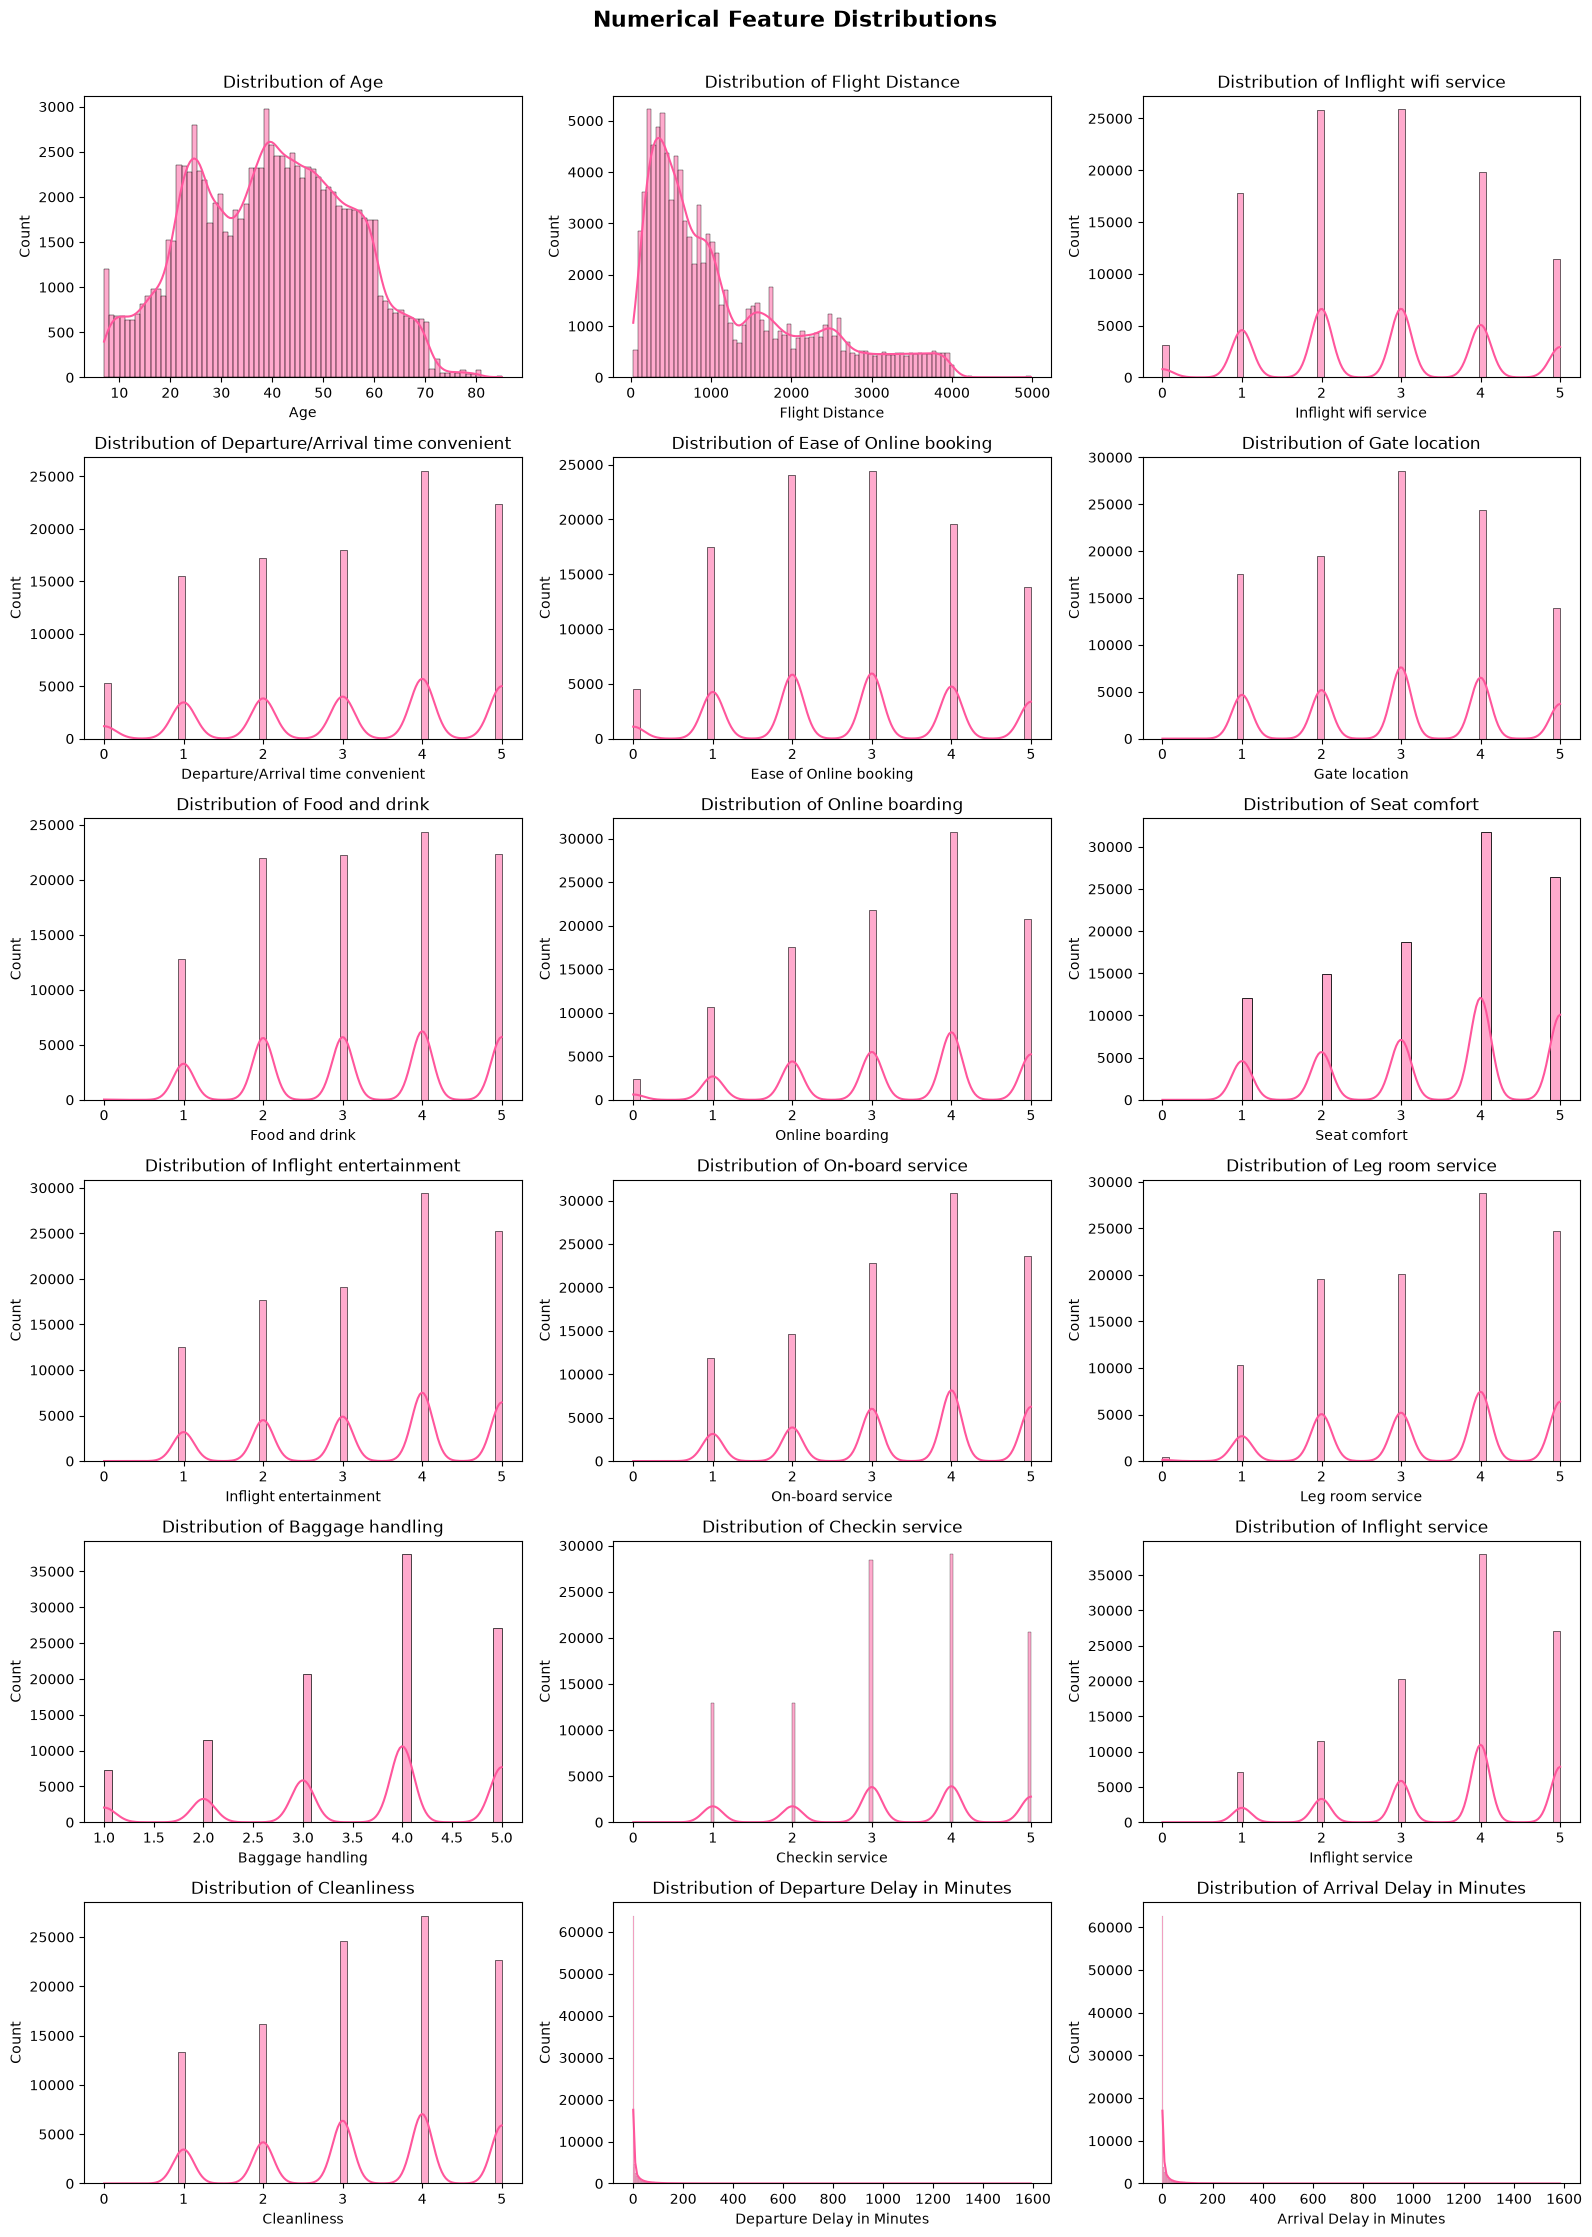

In [21]:
plt.figure(figsize=(16, 25))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(7, 3, i)
    sns.histplot(data=df, x=feature, fill=True, kde=True, color="#FF569C")
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()
plt.suptitle("Numerical Feature Distributions", fontsize=16, y=1.02, fontweight='bold')
plt.show()


# Bivariate Analysis of categorical variables

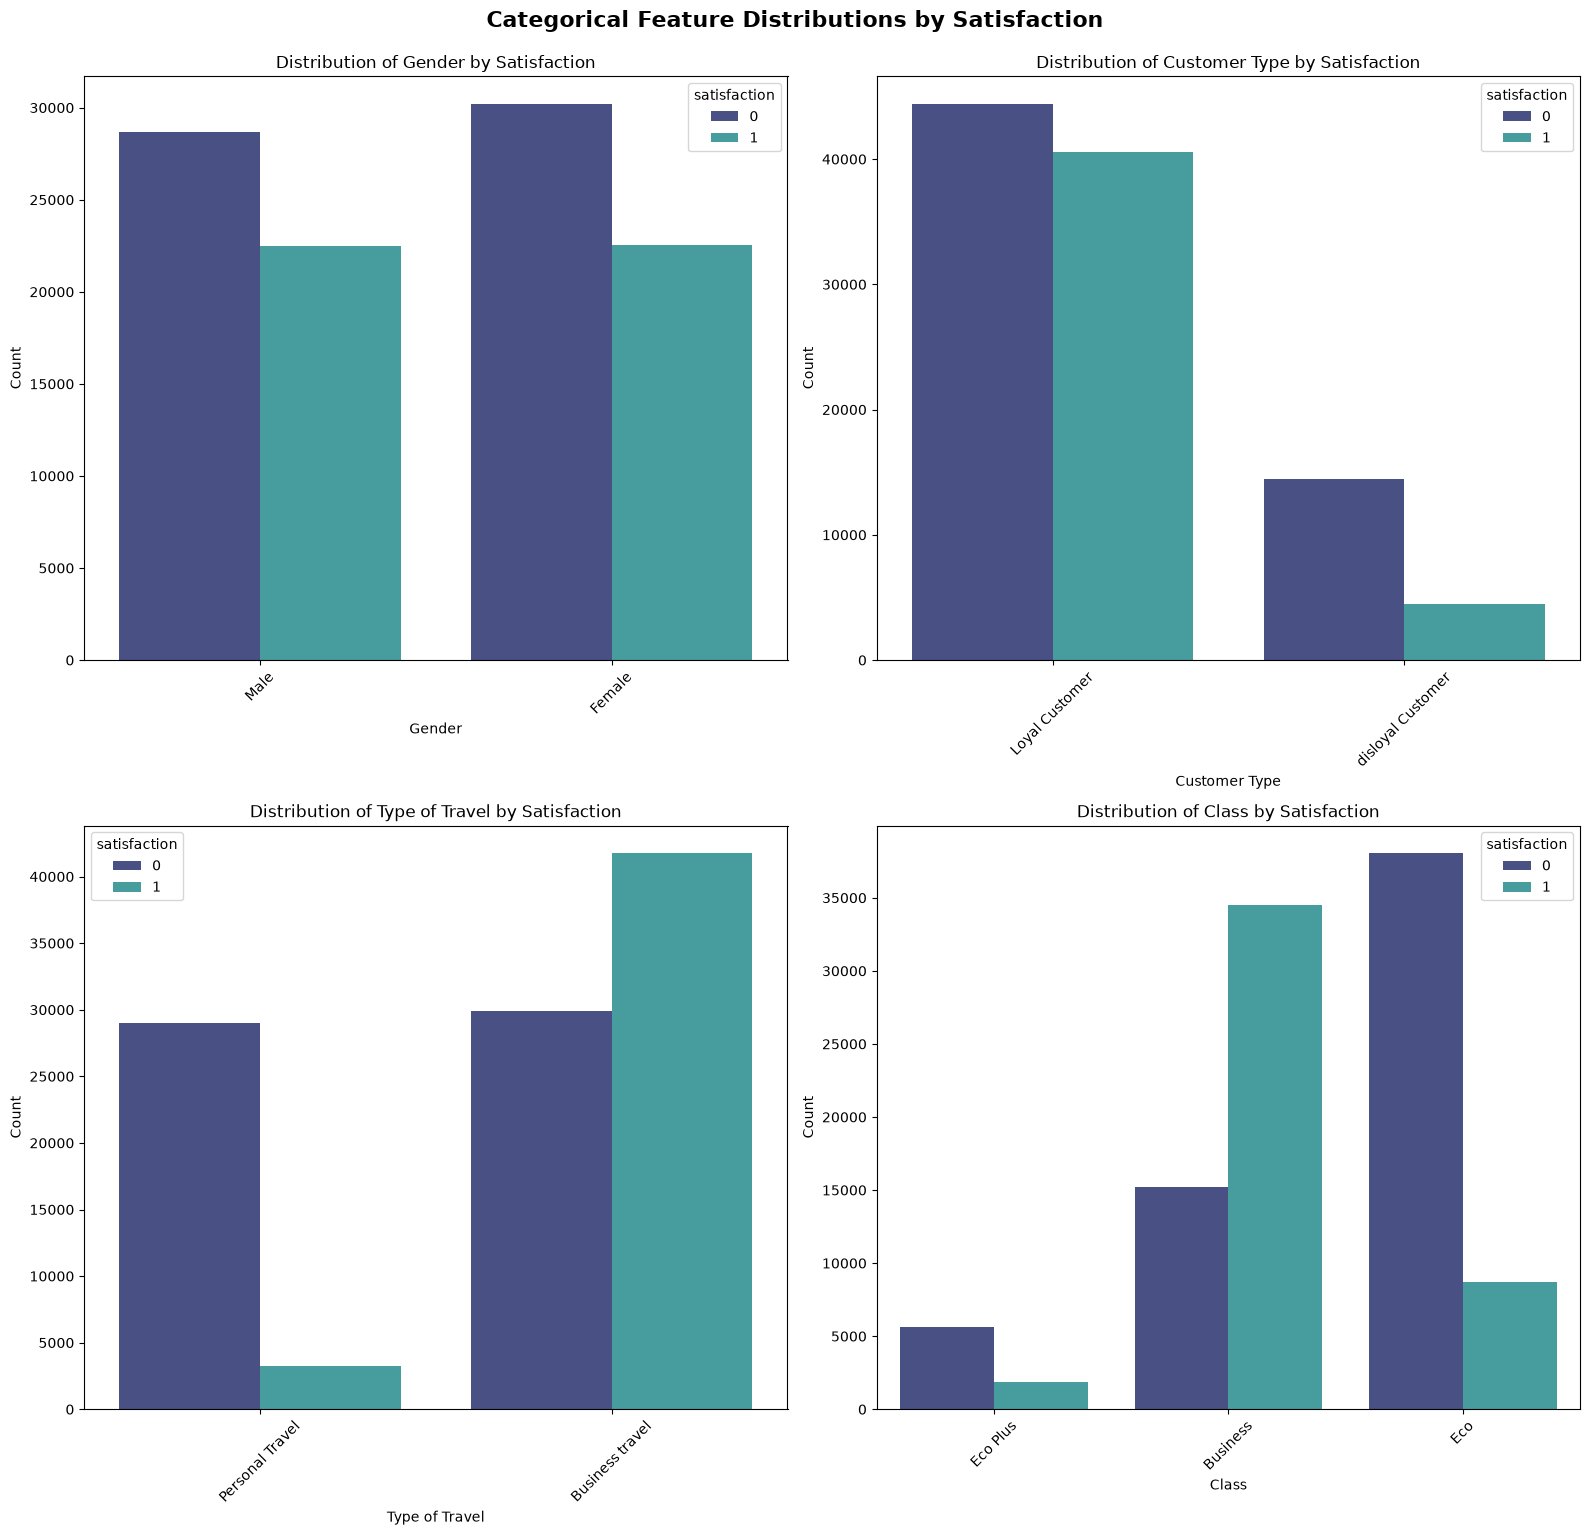

In [22]:
plt.figure(figsize=(16, 15))
for i, feature in enumerate(categorical_columns, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=feature, hue='satisfaction', palette='mako')
    plt.title(f'Distribution of {feature} by Satisfaction')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle("Categorical Feature Distributions by Satisfaction", fontsize=16, y=1.02, fontweight='bold')
plt.show()


**Travel Type Matters**
* Business travelers are much more likely to be satisfied.
* Personal travelers are predominantly dissatisfied.

**Travel Class Matters**
* Business Class passengers show significantly higher satisfaction.
* Economy passengers contribute most dissatisfaction.

**Customer Loyalty Matters**
* Loyal customers show much higher satisfaction than disloyal customers.This suggests loyalty programs directly influence customer experience.

**Gender impact on satisfaction**
* Gender has minimal impact on passenger satisfaction levels.

# Bivariate Analysis of numerical variables

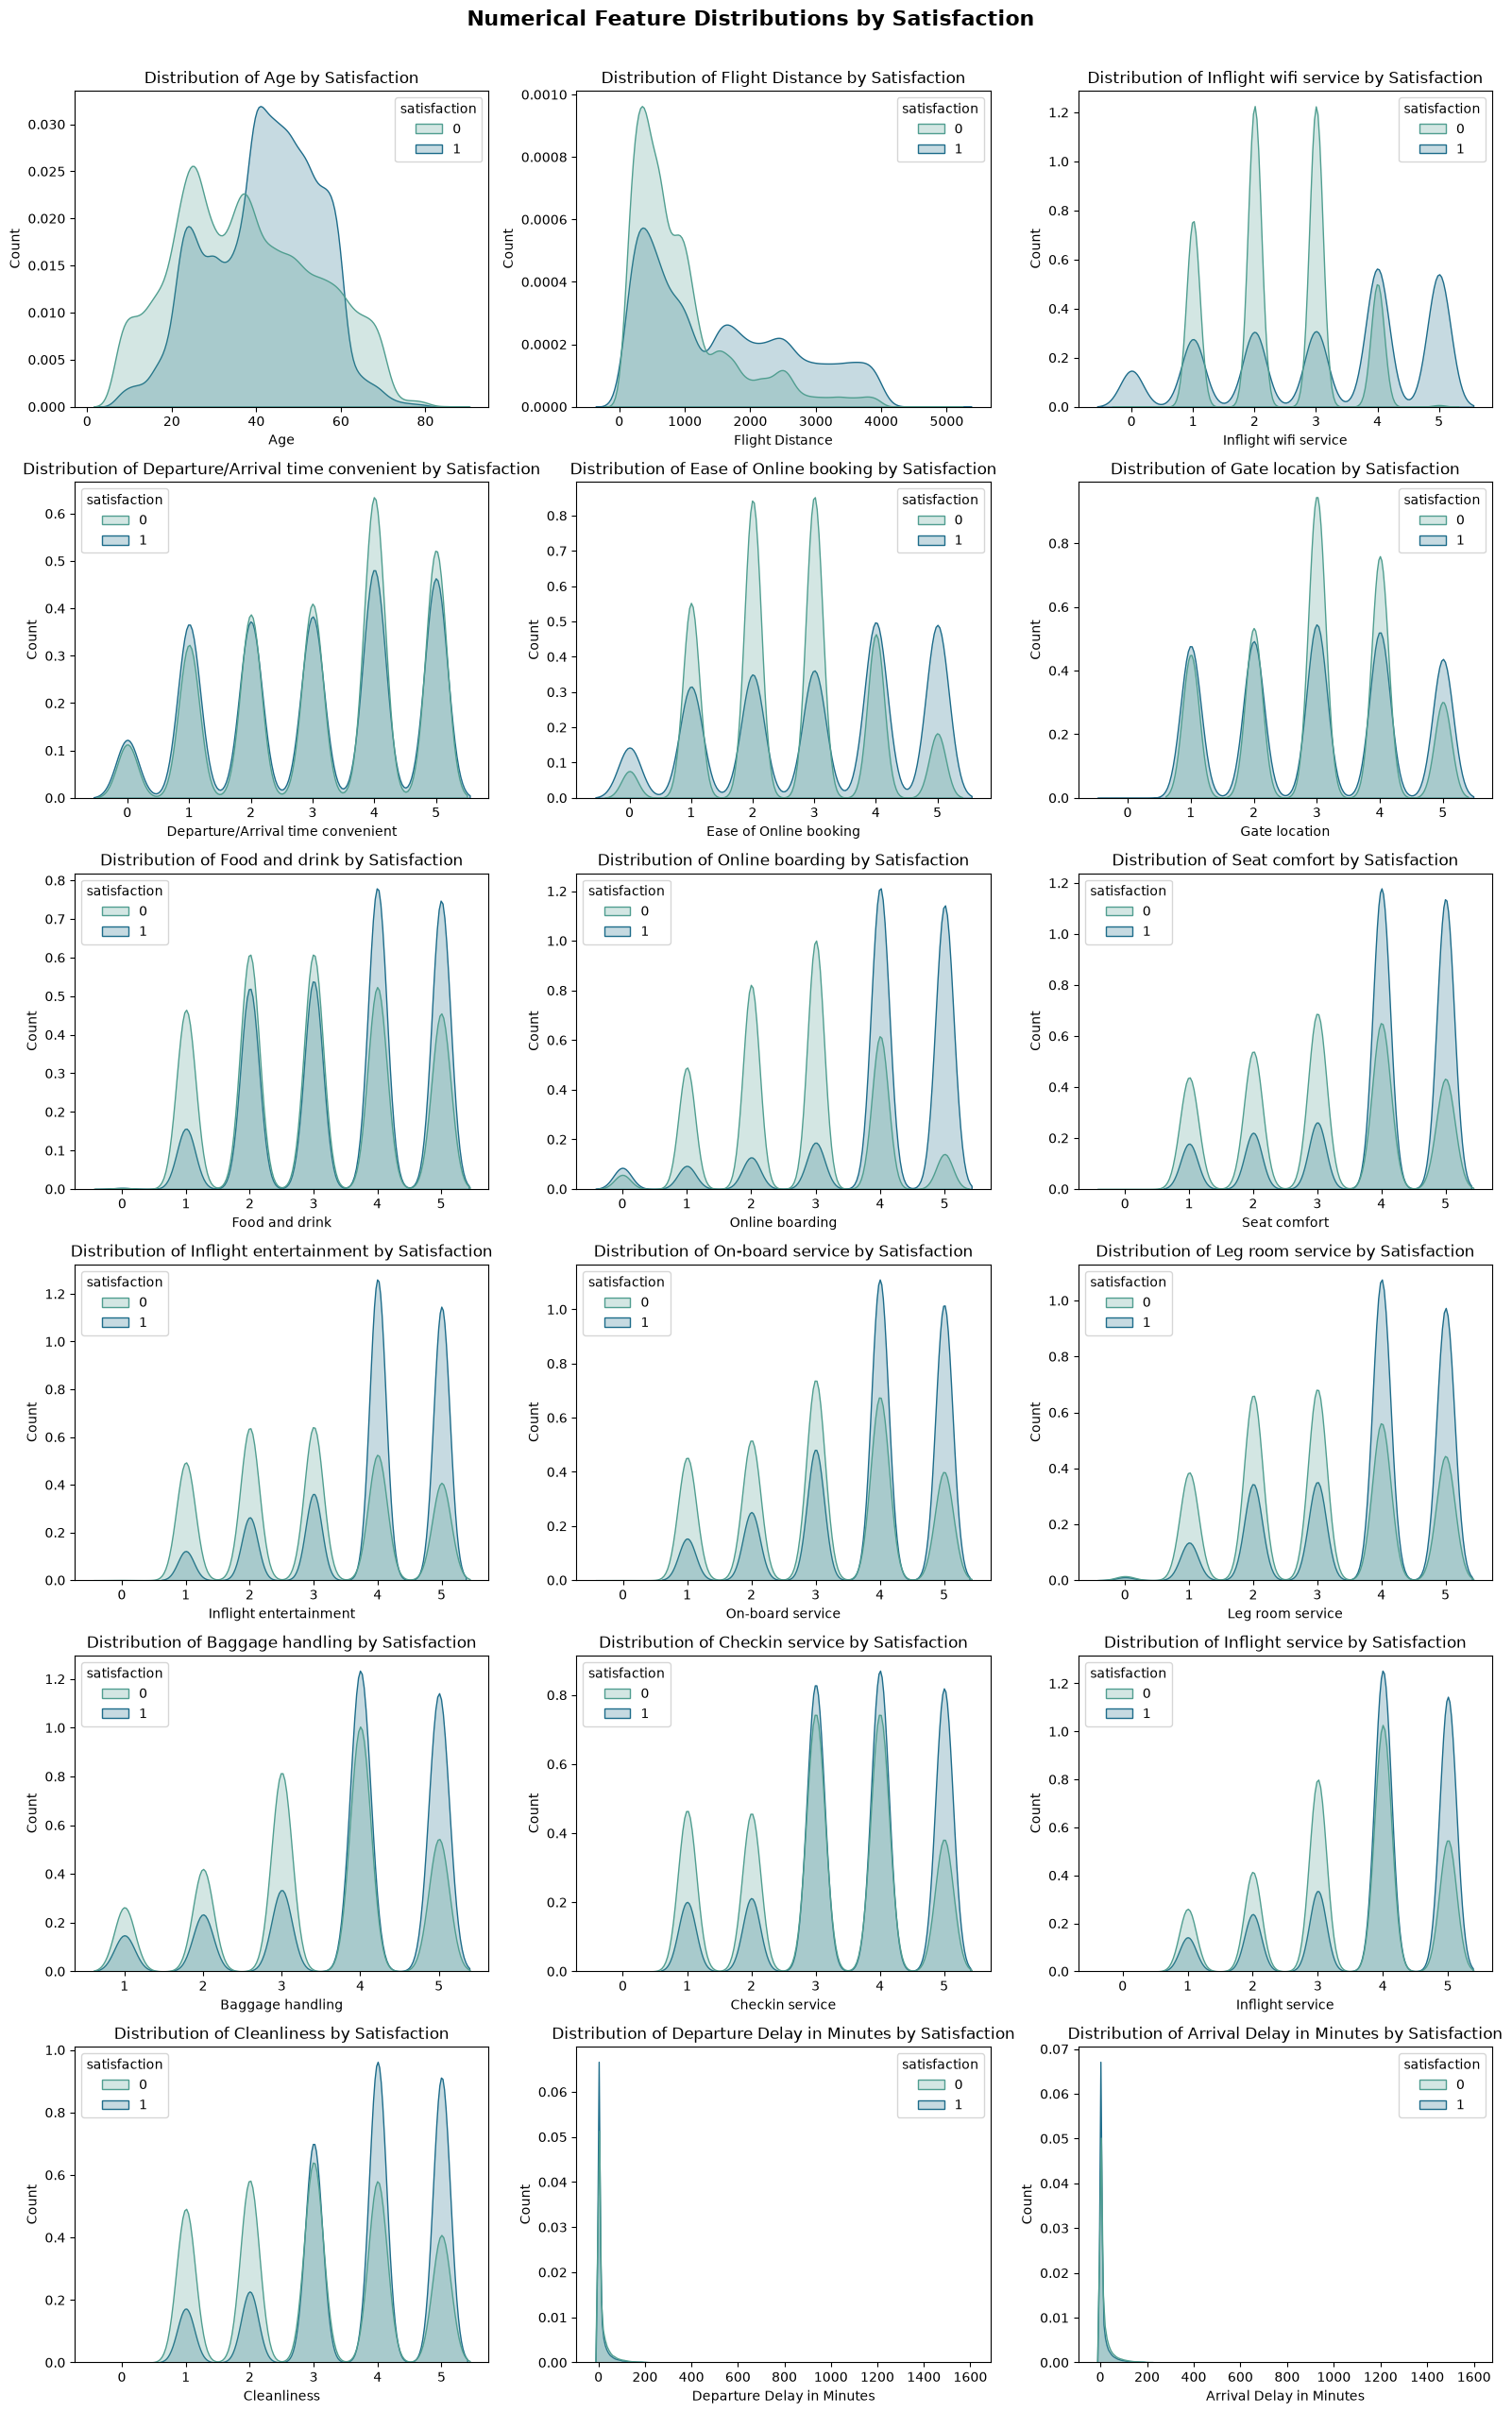

In [23]:
# Distribution Plots 
plt.figure(figsize=(16, 25))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(6, 3, i)
    sns.kdeplot(data=df, x=feature, hue='satisfaction', fill=True, common_norm=False, palette='crest')
    plt.title(f'Distribution of {feature} by Satisfaction')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()
plt.suptitle("Numerical Feature Distributions by Satisfaction", fontsize=16, y=1.02, fontweight='bold')
plt.show()

# Correlation with Satisfaction

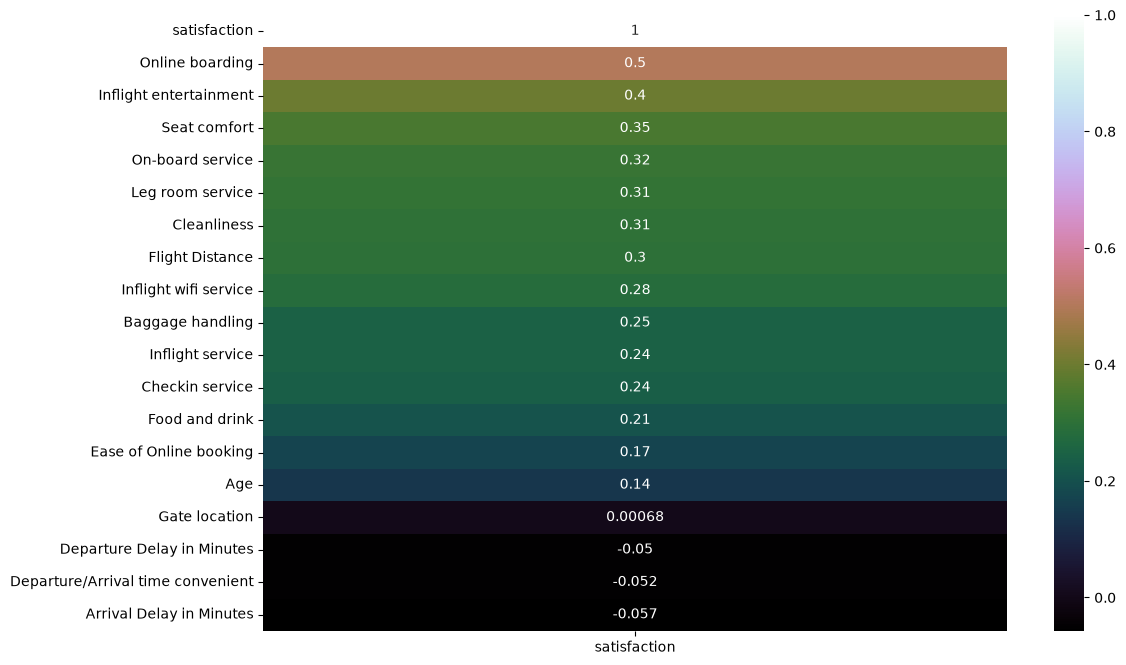

In [24]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr[['satisfaction']].sort_values(by='satisfaction', ascending=False),annot=True,cmap='cubehelix')
plt.show()

## Strongest Business Drivers

| Feature | Correlation with Satisfaction |
| :--- | :--- |
| Online boarding | 0.50 |
| Inflight entertainment | 0.40 |
| Seat comfort | 0.35 |
| On-board service | 0.32 |
| Leg room service | 0.31 |
| Cleanliness | 0.31 |

**Conclusion:** Passenger satisfaction is driven primarily by service quality rather than delays.

# Feature Engineering

In [25]:
df['Total_Delay'] = (df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes'])

In [26]:
df['Delayed_Flight'] = (df['Total_Delay'] > 15).astype(int)

In [27]:
service_columns = [
    'Inflight wifi service',
    'Ease of Online booking',
    'Gate location',
    'Food and drink',
    'Online boarding',
    'Seat comfort',
    'Inflight entertainment',
    'On-board service',
    'Leg room service',
    'Baggage handling',
    'Checkin service',
    'Inflight service',
    'Cleanliness'
]

df['Average_Service_Rating'] = df[service_columns].mean(axis=1)

**A long-haul flight is generally defined as any flight typically covering a distance of over 3,000 to 4,000 miles**

In [28]:
df['Long_Haul'] = (df['Flight Distance'] > 3000).astype(int)

In [29]:
df[['Total_Delay', 'Delayed_Flight', 'Average_Service_Rating', 'Long_Haul']].head()

,Total_Delay,Delayed_Flight,Average_Service_Rating,Long_Haul
0,43.0,1,3.846154,0
1,7.0,0,2.307692,0
2,0.0,0,3.846154,0
3,20.0,1,2.846154,0
4,0.0,0,3.538462,0


In [30]:
df.to_csv("../data/processed_data.csv", index=False)